In [49]:
# =========================
# 📦 CORE LIBRARIES
# =========================
import pandas as pd
import numpy as np

# =========================
# 📊 VISUALIZATION
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# =========================
# ⚙️ PREPROCESSING
# =========================
from sklearn.preprocessing import StandardScaler, LabelEncoder

# =========================
# 🤖 CLUSTERING MODEL
# =========================
from sklearn.cluster import KMeans

# =========================
# 📈 EVALUATION
# =========================
from sklearn.metrics import silhouette_score

# =========================
# ⚠️ WARNINGS
# =========================
import warnings
warnings.filterwarnings("ignore")

In [50]:
df = pd.read_csv("Scraped_data.csv", encoding="latin1")

# Data Cleaning & Preprocessing

In [51]:
# First 5 rows
df.head()

,title,price,rating,availability,UPC,product_type,tax,num_reviews,category,description
0,A Light in the Attic,ÃÂ£51.77,Three,In stock (22 available),a897fe39b1053632,Books,ÃÂ£0.00,0,Poetry,It's hard to imagine a world without A Light i...
1,Tipping the Velvet,ÃÂ£53.74,One,In stock (20 available),90fa61229261140a,Books,ÃÂ£0.00,0,Historical Fiction,"""Erotic and absorbing...Written with starling ..."
2,Soumission,ÃÂ£50.10,One,In stock (20 available),6957f44c3847a760,Books,ÃÂ£0.00,0,Fiction,"Dans une France assez proche de la nÃÂ´tre, u..."
3,Sharp Objects,ÃÂ£47.82,Four,In stock (20 available),e00eb4fd7b871a48,Books,ÃÂ£0.00,0,Mystery,"WICKED above her hipbone, GIRL across her hear..."
4,Sapiens: A Brief History of Humankind,ÃÂ£54.23,Five,In stock (20 available),4165285e1663650f,Books,ÃÂ£0.00,0,History,From a renowned historian comes a groundbreaki...


In [52]:
# Fix encoding issue in price
df["price"] = df["price"].str.replace("ÃÂ£", "").str.replace("£", "")
df["price"] = df["price"].astype(float)

# Fix tax column
df["tax"] = df["tax"].str.replace("ÃÂ£", "").str.replace("£", "")
df["tax"] = df["tax"].astype(float)

# Drop tax (no variation)
df.drop(columns=["tax"], inplace=True)

# Convert rating to numeric
rating_map = {"One":1, "Two":2, "Three":3, "Four":4, "Five":5}
df["rating"] = df["rating"].map(rating_map)

# Extract stock count from availability
df["stock_count"] = df["availability"].str.extract(r"(\d+)").astype(int)

# Drop original availability
df.drop(columns=["availability"], inplace=True)

# Convert num_reviews
df["num_reviews"] = df["num_reviews"].astype(int)

# Final check
df.head()

,title,price,rating,UPC,product_type,num_reviews,category,description,stock_count
0,A Light in the Attic,51.77,3,a897fe39b1053632,Books,0,Poetry,It's hard to imagine a world without A Light i...,22
1,Tipping the Velvet,53.74,1,90fa61229261140a,Books,0,Historical Fiction,"""Erotic and absorbing...Written with starling ...",20
2,Soumission,50.10,1,6957f44c3847a760,Books,0,Fiction,"Dans une France assez proche de la nÃÂ´tre, u...",20
3,Sharp Objects,47.82,4,e00eb4fd7b871a48,Books,0,Mystery,"WICKED above her hipbone, GIRL across her hear...",20
4,Sapiens: A Brief History of Humankind,54.23,5,4165285e1663650f,Books,0,History,From a renowned historian comes a groundbreaki...,20


In [53]:
df.drop(columns=["num_reviews"], inplace=True)

In [54]:
df.drop(columns=["product_type"], inplace=True)

In [55]:
df.head()

,title,price,rating,UPC,category,description,stock_count
0,A Light in the Attic,51.77,3,a897fe39b1053632,Poetry,It's hard to imagine a world without A Light i...,22
1,Tipping the Velvet,53.74,1,90fa61229261140a,Historical Fiction,"""Erotic and absorbing...Written with starling ...",20
2,Soumission,50.10,1,6957f44c3847a760,Fiction,"Dans une France assez proche de la nÃÂ´tre, u...",20
3,Sharp Objects,47.82,4,e00eb4fd7b871a48,Mystery,"WICKED above her hipbone, GIRL across her hear...",20
4,Sapiens: A Brief History of Humankind,54.23,5,4165285e1663650f,History,From a renowned historian comes a groundbreaki...,20


In [56]:
# Adding more columns for better analysis 

In [57]:
df["price_category"] = df["price"].apply(lambda x: "Low" if x < 30 else "High")

In [58]:
df["rating_category"] = df["rating"].apply(lambda x: "Good" if x >= 4 else "Low")

In [59]:
df["price_per_rating"] = df["price"] / df["rating"]

In [60]:
df["stock_pressure"] = df["rating"] / df["stock_count"]

In [61]:
df.head()

,title,price,rating,UPC,category,description,stock_count,price_category,rating_category,price_per_rating,stock_pressure
0,A Light in the Attic,51.77,3,a897fe39b1053632,Poetry,It's hard to imagine a world without A Light i...,22,High,Low,17.256667,0.136364
1,Tipping the Velvet,53.74,1,90fa61229261140a,Historical Fiction,"""Erotic and absorbing...Written with starling ...",20,High,Low,53.740000,0.050000
2,Soumission,50.10,1,6957f44c3847a760,Fiction,"Dans une France assez proche de la nÃÂ´tre, u...",20,High,Low,50.100000,0.050000
3,Sharp Objects,47.82,4,e00eb4fd7b871a48,Mystery,"WICKED above her hipbone, GIRL across her hear...",20,High,Good,11.955000,0.200000
4,Sapiens: A Brief History of Humankind,54.23,5,4165285e1663650f,History,From a renowned historian comes a groundbreaki...,20,High,Good,10.846000,0.250000


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             1000 non-null   object 
 1   price             1000 non-null   float64
 2   rating            1000 non-null   int64  
 3   UPC               1000 non-null   object 
 4   category          1000 non-null   object 
 5   description       998 non-null    object 
 6   stock_count       1000 non-null   int64  
 7   price_category    1000 non-null   object 
 8   rating_category   1000 non-null   object 
 9   price_per_rating  1000 non-null   float64
 10  stock_pressure    1000 non-null   float64
dtypes: float64(3), int64(2), object(6)
memory usage: 86.1+ KB


In [63]:
df.drop(columns=["title", "UPC", "description"], inplace=True)

# title, UPC, description - text & identifier not useful for model

In [64]:
df.head()

,price,rating,category,stock_count,price_category,rating_category,price_per_rating,stock_pressure
0,51.77,3,Poetry,22,High,Low,17.256667,0.136364
1,53.74,1,Historical Fiction,20,High,Low,53.740000,0.050000
2,50.10,1,Fiction,20,High,Low,50.100000,0.050000
3,47.82,4,Mystery,20,High,Good,11.955000,0.200000
4,54.23,5,History,20,High,Good,10.846000,0.250000


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             1000 non-null   float64
 1   rating            1000 non-null   int64  
 2   category          1000 non-null   object 
 3   stock_count       1000 non-null   int64  
 4   price_category    1000 non-null   object 
 5   rating_category   1000 non-null   object 
 6   price_per_rating  1000 non-null   float64
 7   stock_pressure    1000 non-null   float64
dtypes: float64(3), int64(2), object(3)
memory usage: 62.6+ KB


In [66]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

In [67]:
# Check for missing values
df.isnull().sum()

price               0
rating              0
category            0
stock_count         0
price_category      0
rating_category     0
price_per_rating    0
stock_pressure      0
dtype: int64

In [68]:
# prevents division by zero , infinites value
df["price_per_rating"] = df["price"] / df["rating"].replace(0, 1)
df["stock_pressure"] = df["rating"] / df["stock_count"].replace(0, 1)

In [69]:
df["price_per_rating"]

0      17.256667
1      53.740000
2      50.100000
3      11.955000
4      10.846000
         ...    
995    55.530000
996    14.265000
997     3.394000
998    53.980000
999     5.216000
Name: price_per_rating, Length: 1000, dtype: float64

In [70]:
# check for infinite value
np.isinf(df.select_dtypes(include=[np.number])).sum()

price               0
rating              0
stock_count         0
price_per_rating    0
stock_pressure      0
dtype: int64

# Exploratory Data Analysis & Visualization 

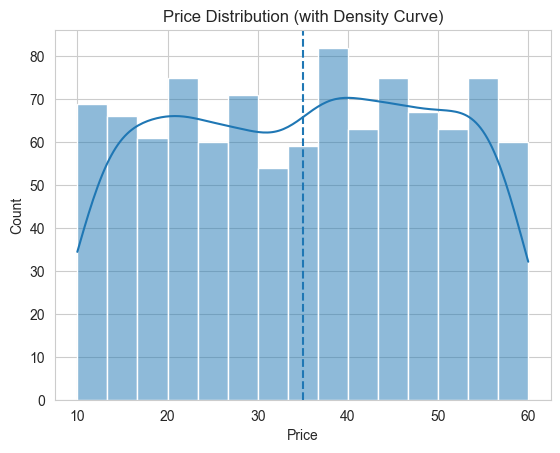

In [71]:
# STEP 1: Understand Distribution of Price

plt.figure()

sns.histplot(df["price"], bins=15, kde=True)

plt.axvline(df["price"].mean(), linestyle="--")

plt.title("Price Distribution (with Density Curve)")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

The price distribution is relatively uniform across the dataset, with products spanning a wide range of prices. The mean price lies near the center, indicating no significant skewness. The smooth density curve confirms that the dataset is well-balanced without extreme outliers.

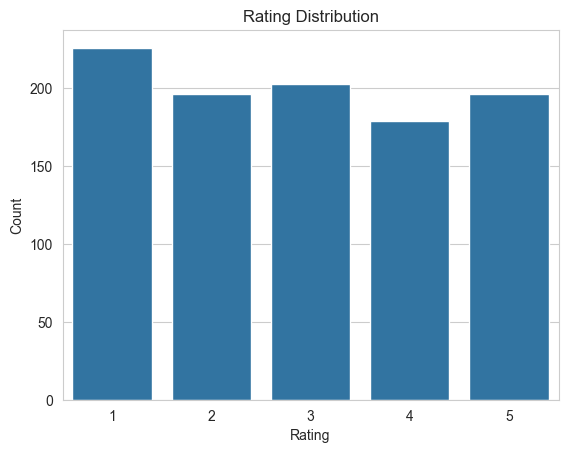

In [72]:
# STEP 2: Rating Distribution

plt.figure()

sns.countplot(x="rating", data=df)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

The rating distribution is relatively balanced across all rating levels, with no single rating dominating the dataset. This indicates that the dataset represents a realistic mix of product quality and customer satisfaction levels

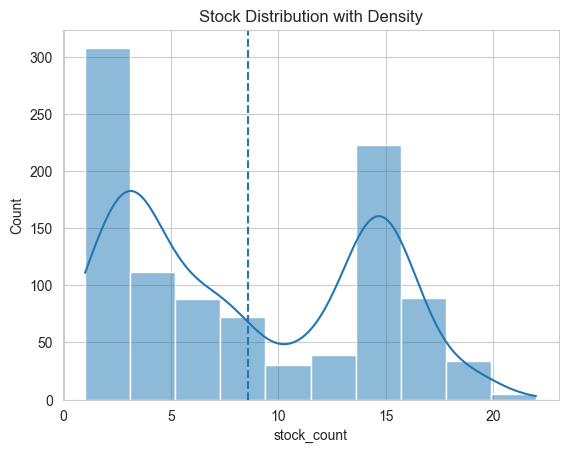

In [73]:
# STEP 3: Stock Availability

sns.histplot(df["stock_count"], bins=10, kde=True)

plt.axvline(df["stock_count"].mean(), linestyle="--")

plt.title("Stock Distribution with Density")
plt.show()

The stock distribution exhibits a bimodal pattern, indicating two distinct groups of products: low-stock items and moderately stocked items. The presence of low-stock products may indicate high demand, while moderately stocked products represent stable inventory. The mean stock lies between these groups, suggesting that average values alone may not fully capture the distribution characteristics.

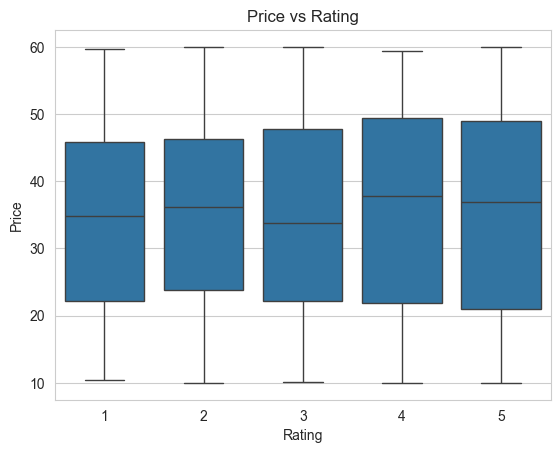

In [74]:
# STEP 4: Price vs Rating 


sns.boxplot(x="rating", y="price", data=df)

plt.title("Price vs Rating")
plt.xlabel("Rating")
plt.ylabel("Price")

plt.show()

The analysis of price versus rating shows no strong relationship between the two variables. Products across all rating levels exhibit a wide price range, indicating that higher-priced products do not necessarily receive better ratings. This suggests that price is not a direct indicator of product quality or customer satisfaction.

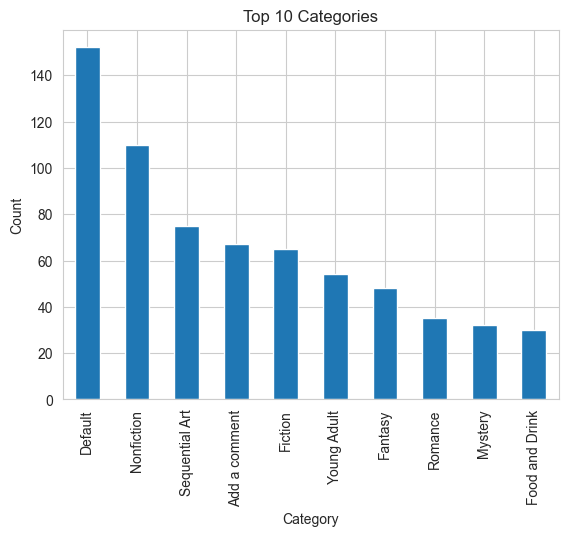

In [75]:
# STEP 5: Category Analysis

top_categories = df["category"].value_counts().head(10)

top_categories.plot(kind="bar")

plt.title("Top 10 Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

In [76]:
# HERE “Default” may be a generic or uncategorized group

The analysis of the top 10 categories shows that a few categories, such as Default and Nonfiction, dominate the dataset, while others have moderate representation. This indicates an imbalanced distribution with a concentration of products in certain categories, along with overall diversity in product types.

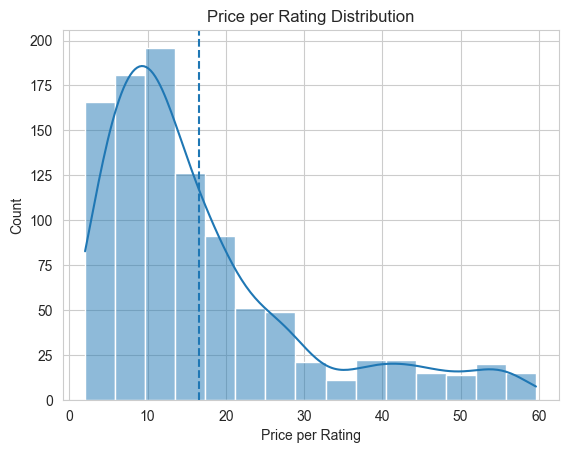

In [77]:
# STEP 6: Price per Rating (VALUE ANALYSIS)

plt.figure()

sns.histplot(df["price_per_rating"], bins=15, kde=True)

plt.axvline(df["price_per_rating"].mean(), linestyle="--")

plt.title("Price per Rating Distribution")
plt.xlabel("Price per Rating")
plt.ylabel("Count")

plt.show()

The price-per-rating distribution is right-skewed, with most products clustered at lower values, indicating good value for money. However, the presence of higher values suggests that some products are relatively overpriced compared to their ratings.

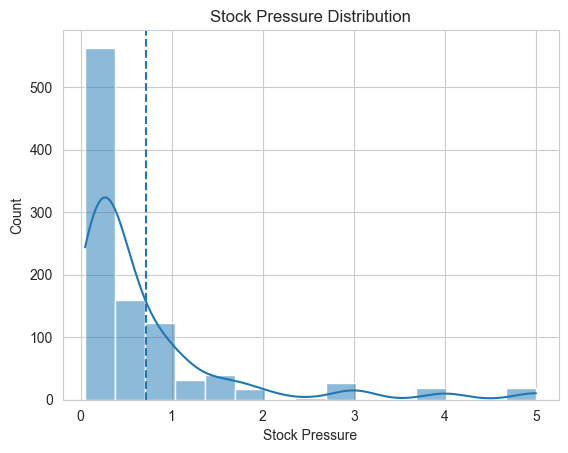

In [78]:
# STEP 7: Stock Pressure (DEMAND INDICATOR)

plt.figure()

sns.histplot(df["stock_pressure"], bins=15, kde=True)

plt.axvline(df["stock_pressure"].mean(), linestyle="--")

plt.title("Stock Pressure Distribution")
plt.xlabel("Stock Pressure")
plt.ylabel("Count")

plt.show()

The stock pressure distribution is highly right-skewed, with most products showing low demand pressure. However, a small number of products exhibit high stock pressure, indicating strong demand relative to availability.

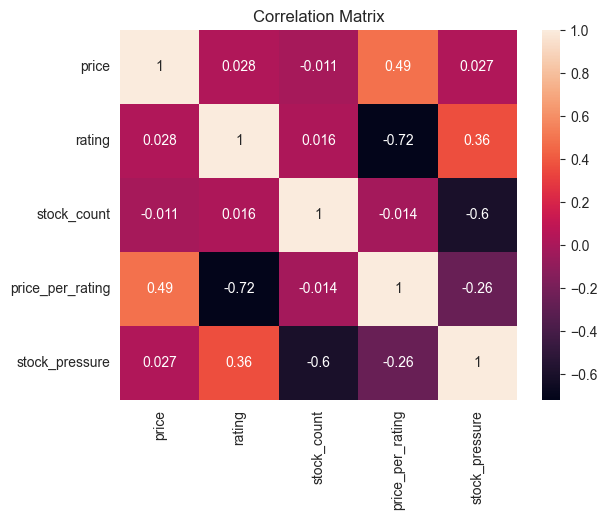

In [79]:
# STEP 8: Correlation Analysis (CRITICAL)

numeric_df = df[[
    "price",
    "rating",
    "stock_count",
    "price_per_rating",
    "stock_pressure"
]]

sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

Price vs Rating → no relation

- Price doesn’t affect satisfaction

Rating vs Price_per_rating → strong negative

- Higher rating → better value

Stock vs Stock_pressure → strong negative

- Low stock → high demand

Rating vs Stock_pressure → positive

- Good products → high demand

The correlation analysis reveals that price has minimal impact on rating and demand, indicating independence. A strong negative correlation between rating and price-per-rating suggests that higher-rated products provide better value for money. Additionally, stock count is negatively correlated with stock pressure, indicating that lower stock levels are associated with higher demand.

# Model Building & Evaluation

In [83]:
# STEP 1: Select Features for Clustering
features = df[[
    "price",
    "rating",
    "stock_count",
    "price_per_rating",
    "stock_pressure"
]]

In [84]:
# STEP 2: Feature Scaling

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [85]:
# STEP 3: Find Optimal Clusters (Elbow Method)
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

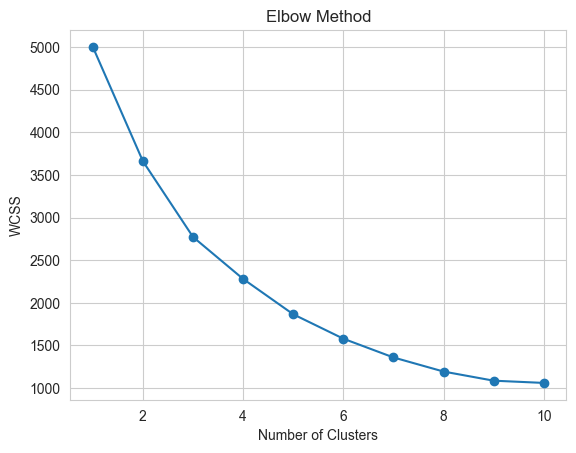

In [86]:
# Plot Elbow Graph

plt.plot(range(1, 11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

The Elbow Method was used to determine the optimal number of clusters. The graph shows a clear bend at K = 4, indicating that four clusters provide the best balance between minimizing WCSS and avoiding overfitting.

In [87]:
kmeans = KMeans(n_clusters=4, random_state=42)

df["cluster"] = kmeans.fit_predict(scaled_features)

In [88]:
# STEP 5: Analyze Clusters

# Check cluster distribution
df["cluster"].value_counts()

cluster
0    323
2    273
3    215
1    189
Name: count, dtype: int64

In [89]:
# Cluster-wise summary
numeric_cols = [
    "price",
    "rating",
    "stock_count",
    "price_per_rating",
    "stock_pressure"
]

df.groupby("cluster")[numeric_cols].mean()

,price,rating,stock_count,price_per_rating,stock_pressure
cluster,,,,,
0,38.839257,3.947368,12.978328,10.672901,0.345810
1,46.845185,1.333333,8.777778,38.645159,0.274562
2,21.856154,1.967033,8.000000,13.625406,0.375284
3,35.836279,3.995349,2.558140,9.770374,2.110930


K-Means clustering identified four distinct product segments: high-demand high-quality products, overpriced low-quality products, budget products with lower ratings, and balanced products with stable performance. These clusters provide valuable insights into pricing strategy, customer satisfaction, and demand patterns.

In [90]:
# STEP 8: Cluster Visualization

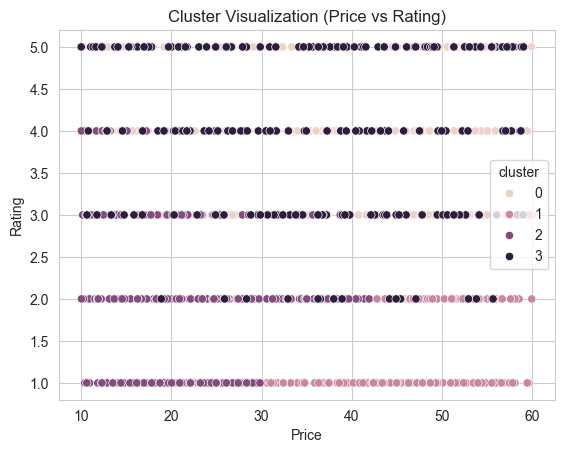

In [91]:
# STEP 8.1: Price vs Rating 
plt.figure()

sns.scatterplot(
    x=df["price"],
    y=df["rating"],
    hue=df["cluster"]
)

plt.title("Cluster Visualization (Price vs Rating)")
plt.xlabel("Price")
plt.ylabel("Rating")

plt.show()

No clear separation based only on price + rating

Meaning:

Clustering is not based on just 2 features
It uses combined features (good!)

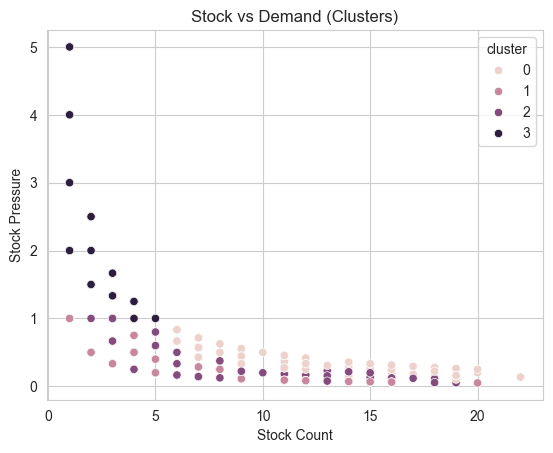

In [92]:
# STEP 8.2: Stock vs Demand
plt.figure()

sns.scatterplot(
    x=df["stock_count"],
    y=df["stock_pressure"],
    hue=df["cluster"]
)

plt.title("Stock vs Demand (Clusters)")
plt.xlabel("Stock Count")
plt.ylabel("Stock Pressure")

plt.show()

High stock → low pressure
Low stock → high pressure

Strong inverse relationship between stock & demand

Cluster separation is visible

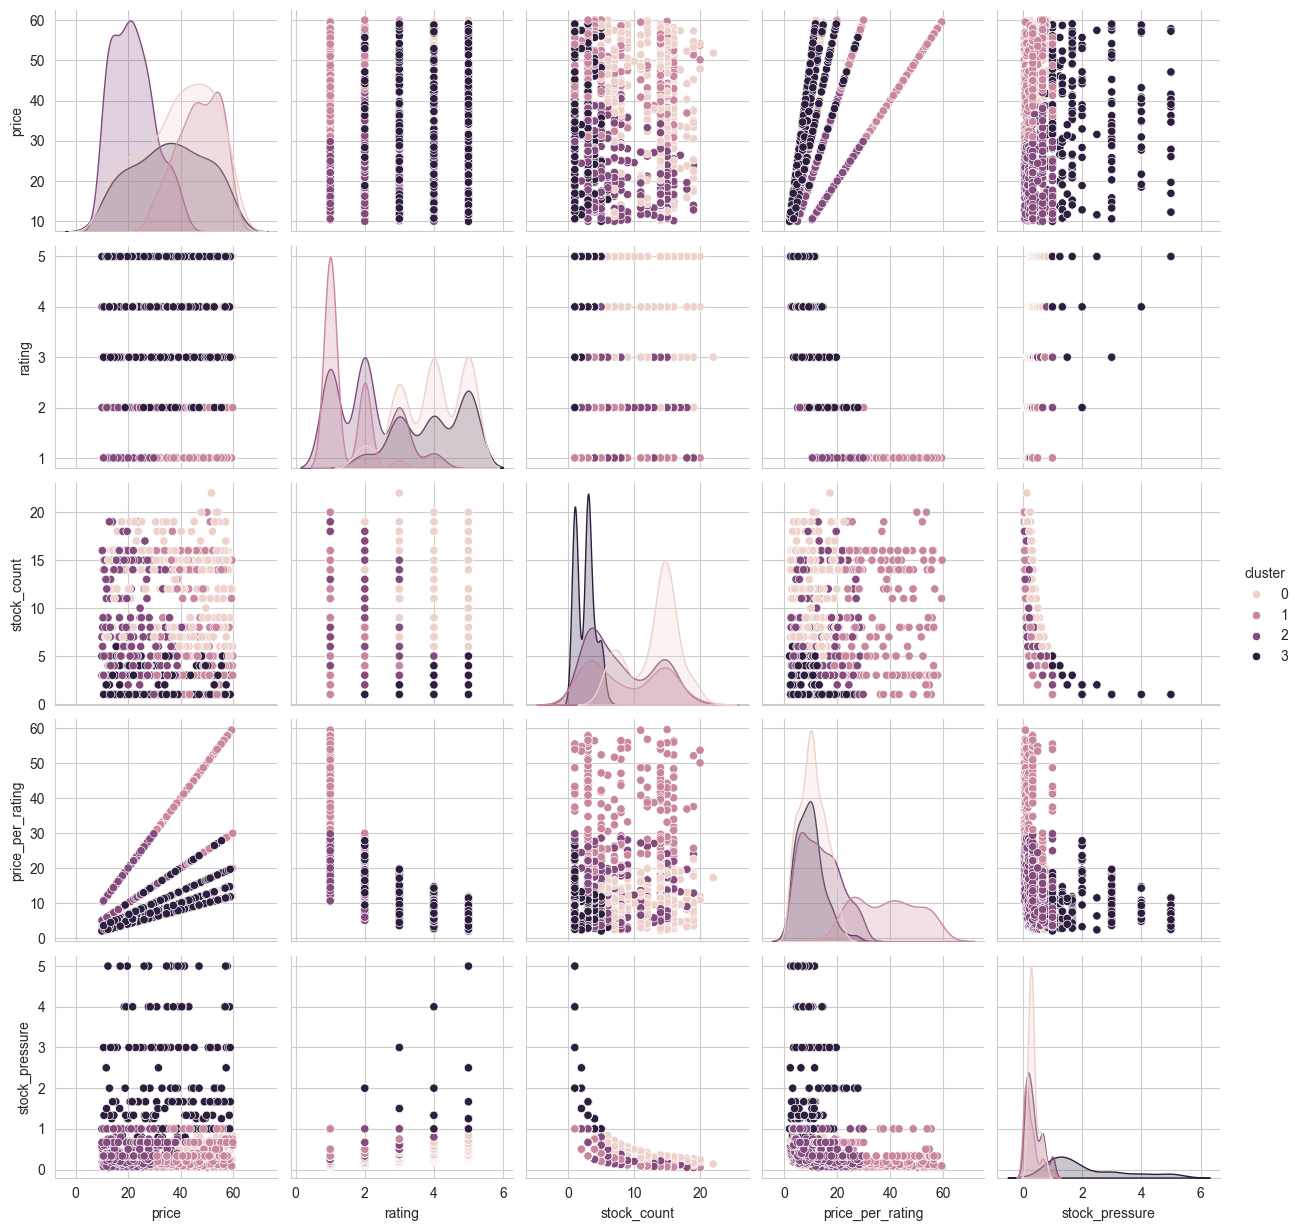

In [93]:
# STEP 8.3: Pair Plot 
sns.pairplot(df, hue="cluster")

Derived features like price-per-rating and stock pressure play a key role in cluster formation.

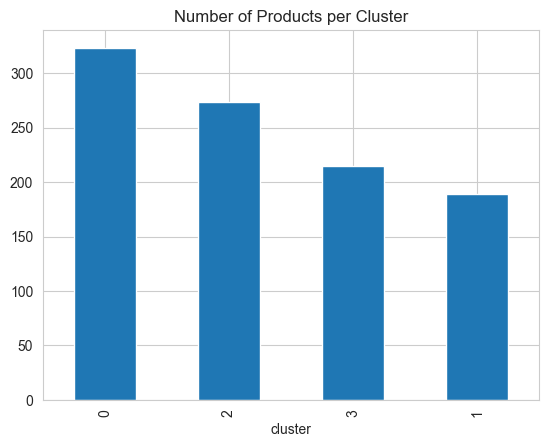

In [94]:
# STEP 8.4: Cluster Count
df["cluster"].value_counts().plot(kind="bar")

plt.title("Number of Products per Cluster")
plt.show()

Dataset distribution:

Most products → balanced
Fewer products → extreme cases

Most products fall into balanced and budget categories, while fewer belong to extreme clusters like overpriced or high-demand.

The clustering results reveal distinct product segments based on value and demand characteristics. Visual analysis confirms that derived features such as price-per-rating and stock pressure play a significant role in cluster separation. The model successfully identifies high-demand products, overpriced items, and balanced product groups, providing actionable business insights.

In [96]:
## Now lets move to INTERACTIVE DASHBOARD - it is done in PowerBI

In [95]:
df.to_csv("cleaned_data.csv", index=False)